# 12 · Recovery that changes the world

## Learning objectives

- Compose fallback with repair and retry.
- Bound repeated attempts.
- Distinguish expected failure from programming errors.

**Environment:** the standalone Python kernel from the README. No ROS installation or sourcing is needed. Run all cells from top to bottom; each notebook starts with its own state.

## Intuition

Retrying a blocked action without changing anything often repeats the same failure.
A **recovery subtree** attempts a repair and then tries again. A selector expresses “normal
path, otherwise recovery”; a sequence expresses “repair, then retry.” Expected operational
failures should return FAILURE. Programming mistakes should remain visible rather than being
hidden by a broad exception handler.

In [2]:
import py_trees as pt
from behavior_trees_tutorial.behaviors.common import Function, CountTicks, Status
from behavior_trees_tutorial.visualization import diagram, trace, playground
from IPython.display import display

## Minimal working example

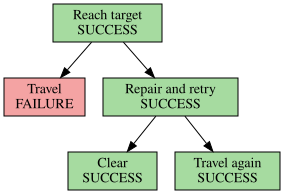

In [3]:
state = {"blocked": True, "repairs": 0}

def travel():
    return Status.FAILURE if state["blocked"] else Status.SUCCESS

def clear_obstacle():
    state["blocked"] = False
    state["repairs"] += 1
    return Status.SUCCESS

root = pt.composites.Selector("Reach target", memory=False, children=[
    Function("Travel", travel),
    pt.composites.Sequence("Repair and retry", memory=True, children=[
        Function("Clear", clear_obstacle), Function("Travel again", travel)])])
root.tick_once()
assert root.status is Status.SUCCESS and state["repairs"] == 1
display(diagram(root))

## Step-by-step implementation
This recovery makes at most two travel attempts in one invocation. If repair is itself
asynchronous, its RUNNING result propagates naturally. A retry decorator can bound several
invocations, but restarting the entire subtree may repeat side effects. Prefer operations
that are **idempotent**: repeating them has the same intended effect as doing them once.

In [4]:
always_fails = pt.decorators.Retry("Budget: three failures",
    pt.behaviours.Failure("Unavailable"), num_failures=3)
rows = trace(always_fails, 3)
assert [row["Budget: three failures"] for row in rows] == ["RUNNING", "RUNNING", "FAILURE"]

1 Budget: three failures: RUNNING | Unavailable: FAILURE
2 Budget: three failures: RUNNING | Unavailable: FAILURE
3 Budget: three failures: FAILURE | Unavailable: FAILURE


## Interactive demonstration

In [5]:
display(playground(lambda: pt.decorators.Retry(
    "Try three times", pt.behaviours.Failure("Still unavailable"), num_failures=3)))

## Key observations

Recovery should alter a cause, choose another path, or wait for a meaningful change. An unbounded retry is not robustness.

## Exercises

1. Make Clear fail and predict the tree result.
2. Add a retry budget around recovery and count actual travel attempts.

Hints and worked solutions: `exercises/README.md` and `solutions/README.md` (lesson 12).

## Summary

Control rules now express priorities, progress, and recovery. Good tree design makes those policies visible at the right level.